**Машинное обучение в экономике**

**Семинар 4. Логистическая регрессия и метод опорных векторов**

Установка библиотек

In [ ]:
!python.exe -m pip install --upgrade pip
!pip install numpy==1.26.4
!pip install pandas # 1.5.3
!pip install scikit-learn
!pip install openpyxl
exit()

/bin/bash: line 1: python.exe: command not found
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 925.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 22.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


In [ ]:
# Подключим необходимые библиотеки
import numpy as np                                        # базовые операции с массивами
import pandas as pd                                       # базовые операции с датафреймами
from sklearn import tree                                  # решающие деревья
from sklearn.model_selection import train_test_split      # разделение выборки
from sklearn.ensemble import GradientBoostingClassifier   # градиентный бустинг
from copy import deepcopy
from scipy.optimize import approx_fprime, minimize, line_search
import matplotlib.pyplot as plt                           # графики
from mpl_toolkits.mplot3d import Axes3D                   # 3D графики
from sklearn.linear_model import LogisticRegression       # логистическая регрессия
import math
from sklearn.neighbors import KNeighborsRegressor         # метод ближайшие соседей
import scipy                                              # распределения
from xgboost import XGBClassifier                         # продвинутый бустинг
from sklearn.model_selection import GridSearchCV          # подбор гиперпараметров

**Генерация данных** 🐰

In [ ]:
# Для воспроизводимости
np.random.seed(777)

# Число наблюдений
n = 1000

# Названия переменных
features_names = ["age", "educ", "married", "nchildren", "work", "income"]

# Число признаков
m = len(features_names)

# Ковариации
sigma = np.empty(shape=(m, m), dtype = 'object')
sigma = pd.DataFrame(np.ones(shape=(m, m), dtype = 'object'),
                     index = features_names,
                     columns = features_names)
  # age
sigma.loc["age", "educ"] = 0.3
sigma.loc["age", "married"] = 0.4
sigma.loc["age", "nchildren"] = 0.5
sigma.loc["age", "work"] = 0.3
sigma.loc["age", "income"] = 0.4
  # educ
sigma.loc["educ", "married"] = 0.3
sigma.loc["educ", "nchildren"] = -0.1
sigma.loc["educ", "work"] = 0.5
sigma.loc["educ", "income"] = 0.6
  # married
sigma.loc["married", "nchildren"] = 0.5
sigma.loc["married", "work"] = 0.3
sigma.loc["married", "income"] = 0.2
  # nchildren
sigma.loc["nchildren", "work"] = 0.1
sigma.loc["nchildren", "income"] = 0.1
  # work
sigma.loc["work", "income"] = 0.7

# Делаем нижнюю и верхнюю части ковариационной
# матрицы симметричными
for i in range(0, m):
  for j in range(0, i):
    sigma.iloc[i, j] = sigma.iloc[j, i]

# Генирируем данные из многомерного нормального распределения
df = np.random.multivariate_normal(mean = np.zeros(m), cov = sigma, size = n)
df = pd.DataFrame(df)
df.columns = features_names

# Приводим данные к реалистичному виду
  # age
df["age"] = pd.cut(df.loc[:, "age"],
                   bins = scipy.stats.norm.ppf
                     (
                     np.linspace(start = 0, stop = 1, num = 42),
                                 loc = 0, scale = 1
                     ),
                   labels = range(20, 61)
                  )
  # educ
df["educ"] = pd.cut(df.loc[:, "educ"],
                    bins = scipy.stats.norm.ppf
                      (
                        [0, 0.6, 0.9, 1],
                        loc = 0, scale = 1
                      ),
                      labels = range(1, 4)
                   )
  # married
df["married"] = pd.cut(df.loc[:, "married"],
                       bins = scipy.stats.norm.ppf
                         (
                           [0, 0.4, 1],
                           loc = 0, scale = 1
                         ),
                       labels = range(0, 2)
                      )
  # nchildren
df["nchildren"] = pd.cut(df.loc[:, "nchildren"],
                         bins = scipy.stats.norm.ppf(
                           np.concatenate
                             (
                               (
                                 [0],
                                 scipy.stats.poisson.cdf(k = range(0, 10),
                                                         mu = 2),
                                 [1]
                               )
                             ),
                           loc = 0, scale=  1),
                           labels = range(0, 11)
                        )
  # work
df["work"] = pd.cut(df.loc[:, "work"],
                    bins = scipy.stats.norm.ppf
                             (
                              [0, 0.3, 1],
                              loc = 0, scale = 1
                             ),
                    labels = range(0, 2)
                    )
  # income
df["income"] = np.round(
                         scipy.stats.expon.ppf
                           (
                             scipy.stats.norm.cdf(df["income"]), scale = 10
                           )
                       ) + 10

# Конвертируем данные в нужный формат
df = df.astype(float)

# Симулируем покупки
buy_li = (
           2.15 -
           0.03 * df["age"] +
           0.00005 * df["age"] ** 2 -
           0.6 * (df["educ"] == 2.0) -
           0.8 * (df["educ"] == 3.0) +
           0.5 * df["married"] +
           0.2 * df["nchildren"] -
           0.6 * df["work"] -
           0.5 * np.log(df["income"]) +
           0.02 * np.log(df["income"]) * df["nchildren"]
          )
buy_prob = scipy.stats.t.cdf(buy_li * 1.2, df = 5)
df["buy"] = np.random.binomial(n = 1, p = buy_prob, size = n)

# Доля покупок
print({'buy': np.mean(df["buy"])})

# Корреляционная матрица
print(df.astype(float).corr(method = 'pearson'))

# Данные
print(df)

{'buy': 0.394}
                age      educ   married  nchildren      work    income  \
age        1.000000  0.206593  0.334814   0.517540  0.188328  0.302118   
educ       0.206593  1.000000  0.187461  -0.075613  0.301332  0.496044   
married    0.334814  0.187461  1.000000   0.378699  0.239349  0.142047   
nchildren  0.517540 -0.075613  0.378699   1.000000  0.053946  0.108237   
work       0.188328  0.301332  0.239349   0.053946  1.000000  0.439230   
income     0.302118  0.496044  0.142047   0.108237  0.439230  1.000000   
buy       -0.108994 -0.327635  0.085718   0.192214 -0.314806 -0.286803   

                buy  
age       -0.108994  
educ      -0.327635  
married    0.085718  
nchildren  0.192214  
work      -0.314806  
income    -0.286803  
buy        1.000000  
      age  educ  married  nchildren  work  income  buy
0    32.0   2.0      1.0        2.0   1.0    31.0    0
1    23.0   2.0      1.0        0.0   0.0    17.0    0
2    38.0   2.0      1.0        0.0   1.0    24.0  

**Численная оптимизация в одномерном случае** 🐱

Цели ⭐

*   С помощью численной оптимизации минимизировать функцию от одного аргумента.




Запрограммируем функцию $f(x)=x^2-2x$, которая достигает минимума в точке $x=1$.

In [ ]:
# Запрограммируем функцию
def f(x):
  val = x ** 2 - 2 * x
  return (val)

<ipython-input-6-c663d781945f>:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  plt.plot(x, fx, 'ro',


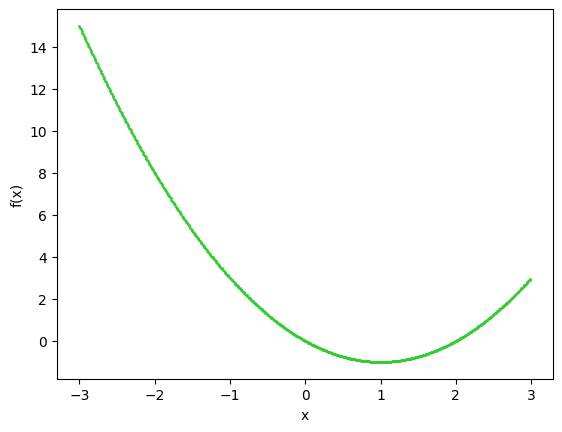

In [ ]:
# Визуализируем функцию
x = np.arange(-3, 3, 0.01)
fx = f(x)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.plot(x, fx, 'ro',
         markersize = 1, color = "limegreen")

Техническое примечание ⚡

Функция `minimize()` позволяет минимизировать функцию `fun` методом `method`, стартуя из начальной точки `x0`. Эта функция возвращает объект, у которого свойство `'x'` является найденной точкой минимума.

Критерии остановки оптимизационного алгоритма функции `minimize()` обычно регулируются аргументами `tol` и `options`. Аргумент `tol` отвечает за допускаемую погрешность решения. Чем меньше `tol`, тем ближе численный максимум к настоящему, но тем дольше будет работать алгоритм. Аргумент `options` можно задать как `options = {maxiter = iter}`, где `maxiter` отвечает за максимально допустимое число итераций алгоритма, что позволяет избежать чрезмерно долгих вычислений, но создает риски получения неточного решения. Однако, это неточное решение можно использовать в качесте начальной точки `x0` при перезапуске алгоритма.

Подробная информация о функции `minimize()` может быть найдена в [документации](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html).

In [ ]:
# Минимизация функции
opt = minimize(fun = f,                    # минимизируемая функция
               x0 = 0.1,                   # начальная точка,
               method = 'Nelder-Mead',     # метод численной оптимизации
               tol = 1e-8,                 # точность алгоритма
               options = {'maxiter': 100}) # число итераций алгоритма

# Найденная точка минимума
print(opt['x'])

Задачи для самоподготовки 🐻

1.   Методами численной оптимизации найдите минимум функции $f(x) = x - \ln(x)$. 🥉
2.   Сравните результаты, выдаваемые функцией `minimize()` при `maxiter = 2`, `maxiter = 10` и `maxiter = 30`. Объясните полученные различия. 🥉
3.   При `maxiter = 5` сравните результаты, выдаваемые алгоритмом при `x0 = 10` и `x0 = 100`. Объясните данные различия. 🥉
4. Методами численной оптимизации найдите **максимум** функции $f(x)=x^3-e^{x}$. 🥈
5. Изучите аргумент `args` функции `minimize()`. Запрограммируйте функцию $f(x) = a x^2 + b x$, где $a$ и $b$ задаются в качестве дополнительных параметров со значениями по умолчанию $a=1$ и $b=1$. Минимизируйте данную функцию при $a=1$ и $b=-5$.🥈





**Численная оптимизация в многомерном случае** 🐱

Цели ⭐

*   С помощью численной оптимизации минимизировать функцию от нескольких аргументов.




Запрограммируем функцию $f(x) = (x_{1}-2)^2+x_{2}^2-x_{1}(x_{2}-1)$, которая, достигает минимума в точке $(x_{1},x_{2})=(2,1)$.

In [ ]:
# Запрограммируем функцию
def f(x):
  val = (x[0] - 2) ** 2 + x[1] ** 2 - x[0] * (x[1] - 1)
  return (val)

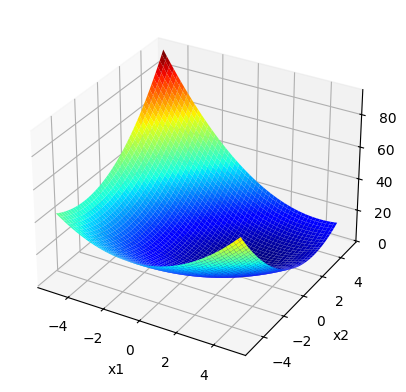

In [ ]:
# Визуализируем функцию
axis_range = np.arange(-5, 5, 0.05)
x1, x2 = np.meshgrid(axis_range, axis_range)
fx = (x1 - 2) ** 2 + x2 ** 2 - x1 * (x2 - 1)
figure = plt.figure()
figure.xlabel = "x1"
axis = figure.add_subplot(projection = '3d')
axis.plot_surface(x1, x2, fx, cmap='jet')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

In [ ]:
# Минимизируем функцию
opt = minimize(fun = f,          # минимизируемая функция
               x0 = (-3, 5),     # начальная точка,
               method = 'BFGS')  # метод численной оптимизации
print(opt['x'])

[1.9999994 0.9999995]


**Численное дифференцирование** 🐱

Цели ⭐

*   С помощью численного дифференцирования найти частную производную функции от нескольких аргументов по одному из аргументов.
*   Запрограммировать функцию для численного дифференцирования и с помощью нее найти градиент функции от нескольких аргументов.




Посчитаем аналитическую производную введенной ранее функции в точке $(x_{1},x_{2})=(1,2)$.

$$\frac{\partial f(x)}{\partial x_{1}} = \frac{\partial \left((x_{1}-2)^2+x_{2}^2-x_{1}(x_{2}-1)\right)}{\partial x_{1}}|_{x_{1}=1,x_{2}=2} = (2x_{1}-x_{2}-3)|_{x_{1}=1,x_{2}=2} = -3$$

Формула численного расчета производной (central difference):

 $$\frac{\partial f(x_{1}, ..., x_{n})}{\partial x_{i}} \approx \frac{f(x_{1},...,x_{i} + \delta,...,x_{n}) - f(x_{1},...,x_{i} - \delta,...,x_{n})}{2\delta}$$

В качестве $\delta$ полагается малое число, например:

*   $\delta = 0.0001$
*   $\delta = \sqrt{\varepsilon} * |x_{i}|$, где $\varepsilon$ - [машинный ноль](https://en.wikipedia.org/wiki/Machine_epsilon).

**Важно** - математически, чем меньше приращение $\delta$, тем точнее численная производная. Однако, если приращение $\delta$ слишком мало, то в силу особенностей арифметики чисел с плавающей точкой, компьютер может не отличить $f(x_{1},...,x_{i} + \delta,...,x_{n})$ от $f(x_{1},...,x_{n})$, поскольку $x_{i}$ и $x_{i}+\delta$ слишком похожи или даже совпадают с точки зрения компьютера. Из-за этого производная будет ошибочно посчитана как равная $0$.

Более подробную информацию можно найти в видео:


*   [Числа с плавающей точкой](https://youtu.be/nJ5dZweMu68?si=Lca9vpb0K_2DK91O).
*   [Численное дифференцирование](https://youtu.be/RKagzF99I6I?si=e8y35ND2MJIny2y8).


 Сравним аналитическую производную с численной.

Техническое примечание ⚡

Если бы мы использовали `x_plus = x` вместо `x_plus = deepcopy(x)`, то переменные `x_plus` и `x` имели бы один и тот же адрес в памяти. В результате код `x_plus[0] = x[0] + delta` изменил бы также значение `x[0]`, поскольку меняя `x_plus` мы изменяли бы и `x`. Функция `deepcopy()` позволяет избежать этого и копирует в `x_plus` лишь значение `x`, а не саму эту переменную, избегая формирования связи между ними.

In [ ]:
# Найдем численный градиент
delta = 0.0001                         # приращения
x = np.array([1.0, 2.0])               # точка, в которой берется производная
x_plus = deepcopy(x)                   # (x1 + delta, x2)
x_plus[0] = x[0] + delta
x_minus = deepcopy(x)                  # (x1 - delta, x2)
x_minus[0] = x[0] - delta
(f(x_plus) - f(x_minus)) / (2 * delta) # численная производная

-2.999999999997449

**Проблема** - при использовании алгоритмов численной оптимизации формулы для производных некоторых функций $f(x)$ могут оказаться чрезвычайно громоздкими и сложными, поэтому их программная реализация занимает очень много времени

**Решение** - воспользоваться численными дифференцированием. Обычно эта процедура уже встроена в оптимизатор. Однако, для наглядности реализуем ее вручную.

**Примечание** - иногда производные по некоторым аргументам функции считаются численно, а по другим, напротив, аналитически.

Техническое примечание ⚡

Запрограммируем функцию `df()` с аргументами:


*   `x` - точка, в которой берется численная производная.
*   `f` - дифференцируемая функция.

In [ ]:
# Запрограммируем функцию для нахождения численного градиента
def grad_f (x, f):
  # квадратный корень из машинного нуля
  eps = np.sqrt(np.finfo(float).eps)
  # минимально допустимое приращение
  min_delta = eps * 100
  # приращение с учетом точности системы
  delta = eps * np.abs(x)
  # контролируем отсутствие слишком малых приращений
  delta[delta <= min_delta] = min_delta
  # число аргументов функции
  n_x = len(x)
  # вектор, в который сохраняются значения градиента
  grad = np.empty(n_x)
  # численное дифференцирование по каждому из аргументов
  for i in range(0, n_x):
    x_plus = deepcopy(x)
    x_plus[i] = x[i] + delta[i]
    x_minus = deepcopy(x)
    x_minus[i] = x[i] - delta[i]
    grad[i] = (f(x_plus) - f(x_minus)) / (2 * delta[i])
  return(grad)

# Проверим функцию
grad = grad_f(x = np.array([1.0, 2.0]), f = f)
print(grad)

[-3.  3.]


**Ручная реализация градиентного спуска** 🐱

Цели ⭐

*   Запрограммировать алгоритм градиентного спуска.
*   Воспользоваться запрограммированным алгоритмом градиентного спуска для нахождения минимума функции.




Реализуем алгоритм градиентного спуска самостоятельно, применяя численное дифференцирование.


Техническое примечание ⚡

Создаваемая функция `gd()` реализует метод градиентно спуска и имеет следующие аргументы:

*   `x` - начальная точка
*   `f` - минимизируемая функция
*   `lr` - скорость обучения (learnin rate)
*   `iter` - число итераций алгоритма

В теле функции переменная `x_vec` представляет собой матрицу, `i`-я строка которой это точка `i`-го шага алгоритма. Поэтому, в качестве первой строки матрицы берется начальная точка `x`.

Каждый шаг алгоритма с помощью запрограммированной ранее функции `df()` рассчитывается градиент в предыдущей точке `x_vec[i - 1, :]` и используется для расчета новой точки `x_vec[i, :]`.

Шаг градиентно спуска:

$$x^{(n + 1)} = x^{(n)} - \alpha \nabla f(x^{(n)})$$

Где $x^{(n)}$ отражает точку, полученную на $n$-м шаге алгоритма.

In [ ]:
# Запрограммируем градиентный спуск
def gd(x, f, lr = 0.1, iter = 100):
  # вектор точек различных итераций алгоритма
  x_vec = np.empty([iter, len(x)])
  # начальная точка
  x_vec[0, :] = x
  for i in range(1, iter):
    # считаем градиент в предыдущей точке
    gradient = grad_f(x = x_vec[i - 1, :], f = f)
    # рассчитываем значение новой точки
    x_vec[i, :] = x_vec[i - 1, :] - lr * gradient
  # возвращаем последнюю найденную точку
  return(x_vec[iter - 1, :])

# Применим градиентный спуск
print(gd(x = np.array([1.0, 1.0]), f = f))

[1.99998524 0.99998524]


Задачи для самоподготовки 🐻

1.   Добавьте в алгоритм дополнительный критерий остановки, когда разница в значениях функции на `i`-м и `i+1`-м шагах оказывается меньше значения `tol`, задаваемого в качестве дополнительного аргумента функции.
2.   Добавьте в градиентный спуск алгоритм линейного поиска с возвратом.





**Загрузка и первичный анализ данных** 🐱

In [ ]:
# Разделим целевую переменную и признаки
target = df.loc[:, ['buy']]                     # целевая переменная
features = df.loc[:, df.columns.drop('buy')]    # матрица признаков
target = np.squeeze(target)                     # преобразуем из вектора столбца
                                                # в одномерный массив

In [ ]:
# Разделим выборку на обучающую и тестовую
features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size = 0.2, random_state = 777)

# Сохраним число наблюдений обучающей и тестовой выборок
n_train = len(target_train)
n_test  = len(target_test)

# Вернем исходную сортировку индексов
features_train = features_train.reset_index(drop = True)
target_train   = target_train.reset_index(drop = True)
features_test  = features_test.reset_index(drop = True)
target_test    = target_test.reset_index(drop = True)

**Логистическая регрессия** 🐱

Цели ⭐

*   Обучить логистическую регрессию.
*   Посчитать условные вероятности и прогнозы с помощью логистической регрессии, а также оценить точность модели на тестовой выборке.




Техническое примечание ⚡

Функция `LogisticRegression()` позволяет обучить логистическую регрессию. Основные параметры:

*   `penalty` - метод регуляризации.
*   `solver` - метод численной оптимизации.
*   `fit_interpect` - логическое значение, отвечающее за включение константы.

Подробная информация может быть найдена в [документации](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html).

In [ ]:
# Обучим логистическую регрессию
logit = LogisticRegression(penalty = None, solver = 'lbfgs',
                           fit_intercept = True)
logit.fit(features_train, target_train)

LogisticRegression(penalty=None)

In [ ]:
# Оценки коэффициентов (без константы)
coef = pd.Series(logit.coef_[-0], index = features.columns)
print(coef)

# Константа
intercept = logit.intercept_
print(intercept)

age         -0.036827
educ        -0.791892
married      0.823099
nchildren    0.424891
work        -1.204311
income      -0.018275
dtype: float64
[1.90967831]


In [ ]:
# Оценки условных вероятностей
prob_logit = logit.predict_proba(features_train)[:, 1]
print(prob_logit[0:10])

[0.71759783 0.09647724 0.37571064 0.10152454 0.52089468 0.14884381
 0.3051784  0.42225853 0.29696686 0.11387372]


In [ ]:
# Прогнозы
prediction_logit = logit.predict(features_train)
print(prediction_logit[0:10])

[1 0 0 0 1 0 0 0 0 0]


In [ ]:
# Точность на тестовой выборке
ACC_test_logit = logit.score(features_test, target_test)
print(ACC_test_logit)

0.775


**Ручная реализация логистической регрессии** 🐱

Цели ⭐

*   Запрограммировать функцию потерь логистической регрессии.
*   Минимизировать функцию потерь по $\beta$ с помощью численного дифференцирования.
*   Сравнить найденные оценки коэффициентов с теми, что были получены ранее.




Функция правдоподобия логистической регрессии:

$$\ln L\left(\beta, X, Y\right) = \sum\limits_{i=1}^{n} -\ln(1 + e^{-X_{i}\beta}) - (1 - Y_{i})X_{i}\beta$$

Функция потерь совпадает с домноженной на $(-1)$ функцией правдоподобия:

$$\text{Loss} = -\ln L\left(\beta, X, Y\right) = \sum\limits_{i=1}^{n} \ln(1 + e^{-X_{i}\beta}) + (1 - Y_{i})X_{i}\beta$$

Техничское примечание ⚡

Поскольку помимо регрессоров у нас также имеется константа, то можно поступить двумя способами:

*   Включить константу в число признаков $X$
*   Без потери общности предположить, что коэффициент $\beta_{0}$, в дальнейшем коде отмечаемый как `beta[0]`, отвечает за константу, а остальные `beta[1:]` - за коэффициенты при признаках.

Будем использовать второй вариант.

Функция `x.dot(beta[1:])` рассчитывает $X_{i}\beta$, где $\beta$ и $X_{i}$ не содержат константу, которая прибавляется отдельно как `beta[0]`, то есть $\beta_{0} + X_{i}\beta$.

In [ ]:
# Запрограммируем функцию потерь как домноженную на
# минус единицу функцию правдоподобия
def Loss(beta, x, y):
      xb = beta[0] + x.dot(beta[1:])                   # b0 + xb
      val = np.log(1 + np.exp(-xb)) + (1 - y) * xb     # функция потерь
      return np.sum(val)

In [ ]:
# Зададим начальную точку как вектор из нулей
x0 = np.zeros(len(features_train.columns) + 1)
print(x0)

[0. 0. 0. 0. 0. 0. 0.]


In [ ]:
# Минимизируем функцию потерь, что эквивалентно
# максимизации функции правдоподобия
opt = minimize(fun = Loss,
               x0 = x0,
               args = (features_train, target_train),
               method = 'BFGS')
coef1 = opt['x'][1:]
intercept1 = opt['x'][0]

Сравним $\hat{\beta}$, полученные нашим методом и пакетом.

In [ ]:
# Сравним наши коэффициенты с полученными ранее
coef_tbl = pd.DataFrame({'Коэффициенты': features.columns,
                         'sclearn':      logit.coef_.flatten(),
                         'Наши':         coef1})
print(coef_tbl)

  Коэффициенты   sclearn      Наши
0          age -0.036827 -0.036824
1         educ -0.791892 -0.791806
2      married  0.823099  0.822975
3    nchildren  0.424891  0.424888
4         work -1.204311 -1.204318
5       income -0.018275 -0.018274


**Градиентный бустинг** 🐱

Цели ⭐

*   Обучить градиентный бустинг.
*   Оценить условные вероятности на как обучающей, так и на тестовой выборках.
*   Сравнить точность градиентного бустинга и логистической регрессии на тестовой выборке.



Техническое примечание ⚡

Функция `GradientBoostingClassifier()` позволяет обучить градиентный бустинг.

Основные аргументы:


*   `loss` - функция потерь.
*   `n_estimators` - число моделей в ансамбле (регрессионных деревьев), то есть количество итераций алгоритма.
*   `learning_rate` - скорость обучения.
*   `criterion` - критерий, используемый при разбиении в регрессионных деревья.
*   `max_depth` - максимальная глубина регрессионных деревьев.
*   `max_features` - максимальная число случайно выбираемых признаков, используемых при очередном разбиении узла.
*   `random_state` - аналог `random.seed()`, гарантирующий воспроизводимость расчетов.


Дополнительная информация может быть найдена в [документации](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html).

In [ ]:
# Воспользуемся градиентным бустингом
learning_rate = 0.5
n_estimators  = 50
max_depth     = 2
random_state  = 123
max_features  = None
gb = GradientBoostingClassifier(loss = "log_loss",             # функция потерь
                                n_estimators = n_estimators,   # число деревьев
                                learning_rate = learning_rate, # скорость обучения
                                criterion = "friedman_mse",    # критерий деревьев
                                max_depth = max_depth,         # глубина деревьев
                                random_state = random_state,   # для воспроизводимости
                                max_features = max_features)   # признаки
gb.fit(features_train, target_train)                           # обучение

GradientBoostingClassifier(learning_rate=0.5, max_depth=2, n_estimators=50,
                           random_state=123)

In [ ]:
# Оценим условные вероятности градиентным бустингом
gb_train = gb.predict_proba(features_train)[:, 1]
gb_test  = gb.predict_proba(features_test)[:, 1]

In [ ]:
# Точность на тестовой выборке
ACC_test_gb = gb.score(features_test, target_test)
print(pd.DataFrame(data    = [ACC_test_logit, ACC_test_gb],
                   index   = ['Логит', 'Градиентный бустинг'],
                   columns = ['ACC тест']))

                     ACC тест
Логит                   0.775
Градиентный бустинг     0.790


Задачи для самоподготовки 🐻

1.   Изучите, как будет соотноситься точность логистической регрессии и градиентного бустинга не тестовой выборке, при различных количества итераций градиентного бустинга `n_estimators`: 2, 10, 50, 300. Сделайте вывод о возможности переобучения градиентного бустинга. 🥉





**Ручная реализация градиентного бустинга** 🐱

Цели ⭐

*   Самостоятельно запрограммировать градиентный бустинг
*   Изучить, как изменяется функция потерь на обучающей и тестовой выборках по мере увеличения числа итераций алгоритма.



Запрограммируем логистическую функцию потерь

$$\text{L}(Y, F(X)) = \frac{1}{n}\sum\limits_{i=1}^{n} -Y_{i}\ln(F(X_{i}))-(1-Y_{i})\ln(1 - F(X_{i}))$$

In [ ]:
# Функция потерь
def log_loss(Y, F):
  # поскольку в градиентном бустинге F может принимать значения
  # меньше 0 или больше 1, этот момент необходимо проконтролировать
  F[F <= 0] = 1e-16
  F[F >= 1] = 1 - (1e-16)
  val = np.mean(-Y * np.log(F) - (1 - Y) * np.log(1 - F))
  return(val)

Запрограммируем производную логистической функции потерь:

$$\frac{\partial\text{L}(Y_{i}, F(X_{i}))}{\partial F(X_{i})} = \begin{cases}\frac{1}{n}\left(\frac{-Y_{i}}{F(X_{i})} + \frac{(1 - Y_{i})}{1 - F(X_{i})}\right)\text{, если }0 < F(X_{i}) < 1\\0\text{, в противном случае}\end{cases}$$

In [ ]:
# Производная функции потерь
def d_log_loss(Y, F):
  val = -Y / F + (1 - Y) / (1 - F)
  val[(F <= 0) | (F >= 1)] = 0
  return(val / len(val))

In [ ]:
# Убедимся в корректности формулы производной
d_log_loss_analytical = np.sum(d_log_loss(target_train, gb_train))
delta = 1e-8
d_log_loss_numeric = np.sum(log_loss(target_train, gb_train + delta) -
                            log_loss(target_train, gb_train)) / delta
print(d_log_loss_analytical, d_log_loss_numeric)

0.08899896912372302 0.08899899706094061


Создадим вектор, который будет хранить значения функции потерь в каждой точке $\text{L}(Y_{i}, F(X_{i}))$.

In [ ]:
# Вектор для сохранения величины функции потерь
log_loss_train = np.zeros(n_estimators)

In [ ]:
# Вектор для сохранения точностей
acc_train_vec = np.zeros(n_estimators)

Вектор для моделей $F_{M}(X)$, где $M$ принимает значения от `1` до `n_estimators`.

In [ ]:
# Вектор для сохранения моделей
model_vec = np.empty(n_estimators, dtype = object)

Создадим регрессионные дерево, указав параметры, с которыми будут обучаться все используемые для прогнозирования градиента регрессионные деревья.

In [ ]:
# Регрессионное дерево
rt = tree.DecisionTreeRegressor(max_depth = max_depth,
                                max_features = max_features,
                                criterion = "friedman_mse",
                                random_state = random_state)

In [ ]:
# Установим скорость обучения
learning_rate = 20

В качестве начальной модели рассмотрим наивную, значение которой совпадает с долей единиц.

$$F_{0}(x) = \frac{1}{n}\sum\limits_{i=1}^{n} Y_{i}$$

In [ ]:
# Начальная модель
model0 = np.mean(target_train)
gb1_train = np.zeros(len(target_train)) + model0

Краткое описание $k$-й итерации алгоритма градиеного бустинга:

*   Для каждого наблюдения рассчитывается остаток:
$$r_{(k+1)i} = -\frac{d \text{L}(Y_{i}, F_{k}(X_{i}))}{d F_{k}(X_{i})}$$
*   Обучаем регрессионное дерево прогнозировать остатки $r_{ki}$ с помощью признаков $X_{i}$. Обозначим обученную (промежуточную) модель как $h_{k}(x)$.
*   Улучшаем итоговую модель с помощью промежуточной, прибавляя ее с коэффиценом $\gamma > 0$, отражающим скорость обучения:
$$F_{k+1}(x) = F_{k}(x) + \gamma h_{k}(x)$$

In [ ]:
# Итеративное обучение модели
for i in range(0, n_estimators):
  # остатки - отрицательные градиенты
  res = -d_log_loss(target_train, gb1_train)
  # модель (регрессионное дерево), прогнозирующая
  # остатки с помощью признаков
  model_vec[i] = deepcopy(rt.fit(features_train, res))
  # прогнозы остатков
  h = model_vec[i].predict(features_train)
  # изменение прогнозов ансамбля
  gb1_train += learning_rate * h
  # значение функции потерь ансамбля
  log_loss_train[i] = np.mean(log_loss(target_train, gb1_train))
  # точность ансамбля
  acc_train_vec[i]  = np.mean((gb1_train >= 0.5).astype(int) == target_train)

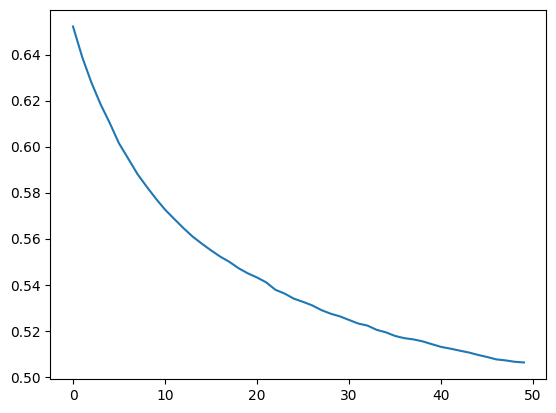

In [ ]:
# Изменение функции потерь с каждой итерацией алгоритма
# на обучающей выборке
plt.plot(log_loss_train)
plt.show()
plt.close()

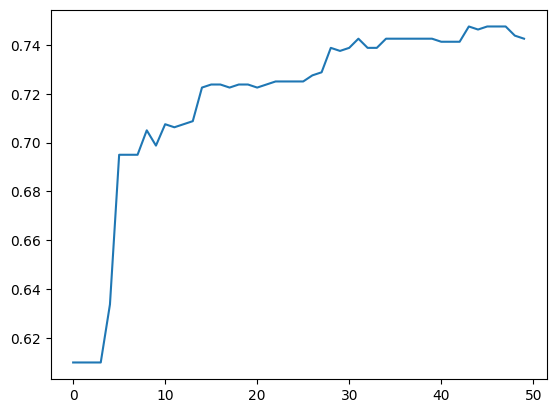

In [ ]:
# Изменение точности с каждой итерацией алгоритма
# на обучающей выборке
plt.plot(acc_train_vec)
plt.show()
plt.close()

Алгоритм градиентного Бустинга пакета `sclearn` немного отличается от того, что мы использовали выше. В частности, в `sclearn` применяется различные техники, позволяющие более точным образом подобрать `learning_rate` для каждой отдельной итерации. Для простоты и няглядности мы опускаем эти особенности в нашей реализации.

In [ ]:
# Сравнение функций потерь ручной и автоматической реализации
gb_log_loss_train  = log_loss(target_train, gb_train)
gb1_log_loss_train = log_loss(target_train, gb1_train)
print(pd.DataFrame(data    = [gb_log_loss_train, gb1_log_loss_train],
                   index   = ['sclearn', 'Наш градиентный бустинг'],
                   columns = ['Функция потерь на обучающей выборке']))

                         Функция потерь на обучающей выборке
sclearn                                             0.451890
Наш градиентный бустинг                             0.506188


Прогноз можно выразить через сумму прогнозов промежуточных моделей:

$$\hat{P}(Y_{i}=1|X_{i}=x) = F_{0}(x) + \gamma \sum\limits_{k=1}^{M}h_{k}(x)$$

In [ ]:
# Прогнозирование на тестовой выборке
log_loss_test = np.zeros(n_estimators)                       # функции потерь
gb1_test = np.zeros(len(target_test)) + model0               # прогнозы ансамбля
for i in range(0, n_estimators):
  h = model_vec[i].predict(features_test)                    # прогнозы остатков
  gb1_test += learning_rate * h                              # прогноз ансамбля
  log_loss_test[i] = np.sum(log_loss(target_test, gb1_test)) # функция потерь

In [ ]:
# Сравнение оценок условных вероятностей ручной и автоматической реализации
# P(Y = 1 | X)
prob_tbl = pd.DataFrame({'sclearn': gb_test,
                         'Наши': gb1_test})
print(prob_tbl)

      sclearn      Наши
0    0.624476  0.687815
1    0.529556  0.597452
2    0.351749  0.226537
3    0.450233  0.374025
4    0.534724  0.406198
..        ...       ...
195  0.417231  0.222570
196  0.182179  0.260176
197  0.876380  0.731271
198  0.314235  0.317320
199  0.350444  0.175987

[200 rows x 2 columns]


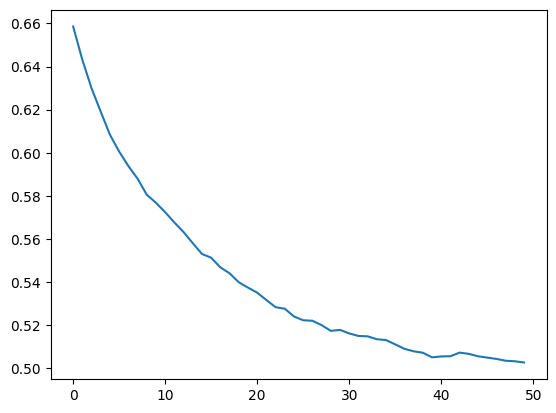

In [ ]:
# Изменение функции потерь с каждой итерацией алгоритма
# на тестовой выборке
plt.plot(log_loss_test)
plt.show()
plt.close()

In [ ]:
# Сравнение функций потерь ручной и автоматической реализации
gb_log_loss_test = log_loss(target_test, gb_test)
gb1_log_loss_test = log_loss(target_test, gb1_test)
print(pd.DataFrame(data    = [gb_log_loss_test, gb1_log_loss_test],
                   index   = ['sclearn', 'Наш градиентный бустинг'],
                   columns = ['Функция потерь на тестовой выборке']))

                         Функция потерь на тестовой выборке
sclearn                                            0.498120
Наш градиентный бустинг                            0.502667


In [ ]:
# Сравнение точностей ручной и автоматической реализаций на тестовой выборке
ACC_test_gb  = np.mean(target_test == (gb_test >= 0.5).astype(int))
ACC_test_gb1 = np.mean(target_test == (gb1_test >= 0.5).astype(int))
print(pd.DataFrame(data    = [ACC_test_gb, ACC_test_gb1],
                   index   = ['sclearn', 'Наш градиентный бустинг'],
                   columns = ['ACC тест']))

                         ACC тест
sclearn                      0.79
Наш градиентный бустинг      0.77


Задачи для самоподготовки 🐻

1. Добавьте гиперпараметр, отвечающий за уменьшение `learning rate` с каждой итерацией алгоритма. Изучите, как соответствующая модификация сказывается на переобучении модели. 🥈

**Градиентный бустинг с помощью XGBoost** 🐱

Цели ⭐

*   Обучить градиентный бустинг с помощью библиотеки `xgboost`.
*   Осуществить подбор оптимальных гиперпараметров с помощью кросс-валидации.



Техническое примечание ⚡

Функция `XGBClassifier()` позволяет применять градиентный бустинг с помощью библиотеки `xgboost`, используя интерфейс, схожий с библиотекой `sclearn`.

Основные аргументы:

*   `n_estimators` - число моделей в ансамбле (регрессионных деревьев), то есть количество итераций алгоритма.
*   `learnin_rate` - скорость обучения.
*   `max_depth` - максимальная глубина регрессионных деревьев.
*   `random_state` - аналог `random.seed()`, гарантирующий воспроизводимость расчетов.
*   `objective` - функция потерь.


Дополнительная информация может быть найдена в [документации](https://xgboost.readthedocs.io/en/stable/python/python_api.html) в разделе `xgboost.XGBClassifier`.

Также, в [документации](https://xgboost.readthedocs.io/en/stable/tutorials/param_tuning.html) может быть найдена информация о тюнинге гиперпараметров.

In [ ]:
# Обучим модель
gb3 = XGBClassifier(n_estimators = 50,
                    max_depth = 3,
                    learning_rate = 0.5,
                    objective = 'binary:logistic',
                    random_state = 123)
gb3.fit(features_train, target_train)

In [ ]:
# Оценим условные вероятности градиентным бустингом
gb3_train = gb3.predict_proba(features_train)[:, 1]
gb3_test  = gb3.predict_proba(features_test)[:, 1]

In [ ]:
# Точность на тестовой выборке
ACC_test_gb3 = gb3.score(features_test, target_test)
print(pd.DataFrame(data    = [ACC_test_logit, ACC_test_gb, ACC_test_gb3],
                   index   = ['Логит', 'Градиентный бустинг sclearn',
                              'Градиентный бустинг xgboost'],
                   columns = ['ACC тест']))

In [ ]:
# Определим набор рассматриваемых гиперпараметров
hyperparameters =  {'max_depth': [2, 3, 4],
                    'learning_rate': [0.1, 0.5, 1],
                    'n_estimators': [20, 50]}

# Применим кросс-валиадцию
GSCV_gb3 = GridSearchCV(estimator = gb3,               # модель
                        param_grid = hyperparameters,  # перебираемые гиперпараметры
                        scoring = "accuracy",          # метрика качества модели
                        cv = 5)                        # число фолдов в кросс-валидации
GSCV_gb3.fit(features_train, target_train)             # подбор гиперпараметров
                                                       # на конкретных данных

In [ ]:
# Достанем гиперпараметры, соответствующие лучшей модели
hyperparameters_best = GSCV_gb3.best_params_
print(hyperparameters_best)

In [ ]:
# Обучим модель с лучшими гиперпараметрами
gb4 = XGBClassifier(n_estimators = hyperparameters_best['n_estimators'],
                    max_depth = hyperparameters_best['max_depth'],
                    learning_rate = hyperparameters_best['learning_rate'],
                    objective = 'binary:logistic',
                    random_state = 123)
gb4.fit(features_train, target_train)

In [ ]:
# Точность на тестовой выборке
ACC_test_gb4 = gb4.score(features_test, target_test)
print(pd.DataFrame(data    = [ACC_test_logit, ACC_test_gb,
                              ACC_test_gb3, ACC_test_gb4],
                   index   = ['Логит', 'Градиентный бустинг sclearn',
                              'Градиентный бустинг xgboost',
                              'Градиентный бустинг xgboost с тюнингом'],
                   columns = ['ACC тест']))

**Решение задачи** 🐱

In [ ]:
# Признак
x = np.array([1, 2, 5, 7, 8]).reshape(-1, 1)
y = np.array([6, 9, 12, 15, 21])

In [ ]:
# Оценим базовую модель
F0 = KNeighborsRegressor(n_neighbors = 3,      # число соседей
                         metric = "minkowski", # метрика расстояния
                         p = 1)                # Манхэттен
F0.fit(x, y)
F0_predict = F0.predict(x)
print(F0_predict)

In [ ]:
# Посчитаем градиент функции потерь
L_grad_neg = -2 * (F0_predict - y)
print(L_grad_neg)

In [ ]:
# Обучим градиент функции потерь
h1 = KNeighborsRegressor(n_neighbors = 2,      # число соседей
                         metric = "minkowski", # метрика расстояния
                         p = 2)                # Евклид
h1.fit(x, L_grad_neg)
h1_predict = h1.predict(x)
print(h1_predict)

In [ ]:
# Выберем скорость обучения
learning_rate = 0.5

In [ ]:
# Получим внутривыборочные прогнозы
F1_predict_train = F0.predict(x) + learning_rate * h1.predict(x)
print(F1_predict_train)

In [ ]:
# Посмотрим на вневыборочные
x_test = np.array([6]).reshape(-1, 1)
F1_predict = F0.predict(x_test) + learning_rate * h1.predict(x_test)
print(F1_predict)